# Outliers, Inconsistencies, and Data Quality

### Lecture notes

**Contents**

| § | Section |
|---|---|
| 1 | Definitions |
| 2 | Detecting outliers |
| 3 | Handling outliers |
| 4 | Inconsistencies |
| 5 | Assessing data quality |
| 6 | Practice problems |
| 7 | Solutions |
| 8 | Glossary |

**How to read these notes.** Sections 1–5 teach. Each idea appears as a
**Definition** followed by one small **Example** worked through in code.
All the exercises are collected in §6, with full solutions in §7, so you can
read the material straight through and then practise.

Every dataset is small enough to check by hand. Nothing is hidden in a file —
run the cells top to bottom and every number is reproduced.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, RED = "#2a78d6", "#e34948"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e8e7e2", "axes.axisbelow": True,
                     "font.size": 9, "figure.facecolor": "white"})
print("ready")

ready


# 1. Definitions

## 1.1 Outlier

> **Definition.** An **outlier** is a value that sits far away from the bulk of the data.
> "Far" only has meaning once you assume a shape for the data, so an outlier is always
> defined *relative to an assumption* — never absolutely.

Outliers come in three kinds, and **the kind decides what you do**:

| Kind | What it is | What to do |
|---|---|---|
| **Error** | A mistake: a typo, a broken sensor, a code meaning "missing" | Fix it or remove it |
| **Contamination** | A real value, but from a different population | Remove it, or model it separately |
| **Genuine extreme** | A real, rare value from the population you meant to study | **Keep it** |

In [2]:
# EXAMPLE. Four flagged values. Statistically similar, but three different causes.
pd.DataFrame({
    "value seen": ["price = -999", "trade of 4,000,000 shares",
                   "response time 14 s", "age = 220"],
    "kind":       ["Error", "Contamination", "Genuine extreme", "Error"],
    "why":        ["a code meaning 'missing', not a price",
                   "an institution trading in a retail table",
                   "a real slow request -- the thing you are paid to find",
                   "no person is 220 years old"],
    "action":     ["convert to missing", "remove from this analysis",
                   "KEEP", "fix or remove"],
})

,value seen,kind,why,action
0,price = -999,Error,"a code meaning 'missing', not a price",convert to missing
1,"trade of 4,000,000 shares",Contamination,an institution trading in a retail table,remove from this analysis
2,response time 14 s,Genuine extreme,a real slow request -- the thing you are paid ...,KEEP
3,age = 220,Error,no person is 220 years old,fix or remove


**The rule to remember:** removing a point needs a **cause**, not just a distance.
A value that is merely large is not thereby wrong.

## 1.2 Inconsistency

> **Definition.** An **inconsistency** is the same fact written two incompatible ways, or
> two values that contradict each other. Unlike an outlier, an inconsistency is usually
> invisible to a statistical test — the values look perfectly ordinary.

| Kind | Example |
|---|---|
| **Representation** | `NYSE`, `nyse`, `" NYSE"` for one venue |
| **Units** | kilograms in some rows, pounds in others |
| **Format** | `2026-03-02` and `03/03/2026` in one column |
| **Contradiction** | a settlement date before the trade date |

## 1.3 Data quality

> **Definition.** **Data quality** is *fitness for a specific purpose*, reported as numbers
> rather than adjectives. There is no absolute quality score: 95% complete is excellent for
> a trend chart and unacceptable for a billing run.

The six dimensions are defined in §5.

# 2. Detecting outliers

## 2.1 The z-score

> **Definition.** The **z-score** measures how many standard deviations a value sits from
> the mean:
> $$z_i = \frac{x_i - \bar{x}}{s}$$
> where $\bar{x}$ is the mean and $s$ the sample standard deviation. Flag when $|z| > 3$.
>
> Symbols: $x_i$ is the $i$-th value, $\bar{x}$ ("x-bar") the mean, $|\cdot|$ the absolute
> value (sign discarded).

In [3]:
# EXAMPLE. Trades per day for ten brokers. One of them is obviously wrong.
x = np.array([22, 24, 25, 25, 26, 27, 28, 29, 31, 120], float)

mean = x.mean()
sd   = x.std(ddof=1)          # ddof=1 -> divide by n-1, the SAMPLE standard deviation
z    = (x - mean) / sd

print(f"mean = {mean:.2f}    sd = {sd:.2f}")
print(f"z-scores: {np.round(z, 2)}")
print(f"largest |z| = {np.abs(z).max():.2f}")
print(f"flagged at |z| > 3: {x[np.abs(z) > 3]}")

mean = 35.70    sd = 29.73
z-scores: [-0.46 -0.39 -0.36 -0.36 -0.33 -0.29 -0.26 -0.23 -0.16  2.84]
largest |z| = 2.84
flagged at |z| > 3: []


**What happened.** The value 120 is plainly wrong — every other broker is near 26. But its
z-score is only **2.84**, so the rule flags **nothing at all**.

Why? Because 120 is itself inside the mean and the standard deviation. It dragged the mean
up to 35.7, inflated the standard deviation to 29.7, and then hid behind its own effect.

There is also a hard limit: for a sample of size $n$, no z-score can ever exceed
$(n-1)/\sqrt{n}$. Here $n = 10$, so the ceiling is $9/\sqrt{10} = 2.85$ — **the rule
$|z|>3$ was incapable of firing before we started.**

## 2.2 The IQR rule

> **Definition.** Sort the data. $Q_1$ is the value one quarter of the way up, $Q_3$ three
> quarters of the way up, and $\mathrm{IQR} = Q_3 - Q_1$ is the width of the middle half.
> Flag anything outside the **fences**
> $$[\,Q_1 - 1.5\,\mathrm{IQR},\;\; Q_3 + 1.5\,\mathrm{IQR}\,]$$
>
> This is the rule a boxplot draws.

In [4]:
# EXAMPLE. Same ten brokers. Same data. Different rule.
q1, q3 = np.percentile(x, [25, 75])
iqr    = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr

print(f"Q1 = {q1:.2f}   Q3 = {q3:.2f}   IQR = {iqr:.2f}")
print(f"fences = [{lo:.3f}, {hi:.3f}]")
print(f"flagged: {x[(x < lo) | (x > hi)]}")

Q1 = 25.00   Q3 = 28.75   IQR = 3.75
fences = [19.375, 34.375]
flagged: [120.]


**What happened.** The value the z-score missed is caught immediately.

$Q_1$ and $Q_3$ depend only on the *rank* of the extreme values, not their size. Whether the
largest value is 120 or 120,000 makes no difference to the fences — which is exactly why an
outlier cannot hide from this rule.

*(Where does 1.5 come from? On normal data those fences sit at 2.70 standard deviations,
flagging about 0.7% of clean values. It is a chosen trade-off: 1.0 flags too much, 2.0 too
little.)*

## 2.3 The modified z-score

> **Definition.** Replace the mean with the **median** ($\tilde{x}$) and the standard
> deviation with the **MAD** (median absolute deviation):
> $$\mathrm{MAD} = \operatorname{median}\big(|x_i - \tilde{x}|\big), \qquad
>   M_i = \frac{0.6745\,(x_i - \tilde{x})}{\mathrm{MAD}}$$
> Flag when $|M| > 3.5$. The constant $0.6745$ puts $M$ on the same scale as an ordinary
> z-score, so the two are directly comparable.

In [5]:
# EXAMPLE. Same ten brokers, third rule.
med = np.median(x)
mad = np.median(np.abs(x - med))       # median of the distances from the median
M   = 0.6745 * (x - med) / mad

print(f"median = {med:.2f}    MAD = {mad:.2f}")
print(f"modified z: {np.round(M, 2)}")
print(f"flagged at |M| > 3.5: {x[np.abs(M) > 3.5]}")

median = 26.50    MAD = 2.00
modified z: [-1.52 -0.84 -0.51 -0.51 -0.17  0.17  0.51  0.84  1.52 31.53]
flagged at |M| > 3.5: [120.]


**What happened.** The modified z-score for 120 is **31.5**, against the z-score's 2.84.
Same value, same dataset — the difference is entirely in the yardstick.

| Rule | Score for 120 | Flags it? |
|---|---|---|
| z-score | 2.84 | **no** |
| IQR | — | yes |
| modified z | 31.5 | yes |

## 2.4 Masking

> **Definition.** **Masking** is what happens when outliers hide each other. Because the mean
> and standard deviation are computed *from* the data, several outliers inflate the standard
> deviation enough that none of them looks unusual any more.
>
> The **breakdown point** measures resistance: the fraction of data that can be made
> arbitrarily bad before a statistic becomes meaningless. Mean and standard deviation: **0%**.
> Median and MAD: **50%**.

In [6]:
# EXAMPLE. Add a SECOND bad broker (118) and redo all three rules.
x2 = np.append(x, 118.0)

z2 = (x2 - x2.mean()) / x2.std(ddof=1)
q1b, q3b = np.percentile(x2, [25, 75]); iqrb = q3b - q1b
med2 = np.median(x2); mad2 = np.median(np.abs(x2 - med2))
M2 = 0.6745 * (x2 - med2) / mad2

print(f"one bad value : sd = {x.std(ddof=1):6.2f}   largest |z| = {np.abs((x-x.mean())/x.std(ddof=1)).max():.2f}")
print(f"two bad values: sd = {x2.std(ddof=1):6.2f}   largest |z| = {np.abs(z2).max():.2f}")
print(f"\nMAD: {mad:.1f} with one bad value, {mad2:.1f} with two -- unchanged")
print(f"\nz-score    flags: {x2[np.abs(z2) > 3]}")
print(f"IQR        flags: {x2[(x2 < q1b-1.5*iqrb) | (x2 > q3b+1.5*iqrb)]}")
print(f"modified z flags: {x2[np.abs(M2) > 3.5]}")

one bad value : sd =  29.73   largest |z| = 2.84
two bad values: sd =  37.57   largest |z| = 2.04

MAD: 2.0 with one bad value, 2.0 with two -- unchanged

z-score    flags: []
IQR        flags: [120. 118.]
modified z flags: [120. 118.]


**What happened.** Adding a second bad value made the first one look *more* normal: the
largest $|z|$ **fell from 2.84 to 2.04**. The data got worse and the z-score got quieter.

The robust rules were unaffected, and the MAD did not move at all.

**This is why robust statistics are the default for detection.** Use the mean to *describe*
data; use the median to *defend against* it.

## 2.5 Skew is not outliers

> **Definition.** A **right-skewed** variable has a long tail of large values *by nature* —
> incomes, transaction sizes, waiting times. The upper tail is not made of errors; it is the
> shape of the distribution.
>
> **Rule of thumb:** if a detector flags more than about **5%** of your rows, it is describing
> the distribution, not finding errors. The fix is to transform first, usually with `np.log`.

In [7]:
# EXAMPLE. Twelve transaction amounts. Nothing here is wrong -- the data is simply skewed.
amt = np.array([120, 150, 180, 210, 260, 320, 410, 550, 780, 1200, 2100, 4500], float)

def iqr_flags(v):
    q1, q3 = np.percentile(v, [25, 75]); s = q3 - q1
    return (v < q1 - 1.5*s) | (v > q3 + 1.5*s)

raw_flags, log_flags = iqr_flags(amt), iqr_flags(np.log(amt))
print(f"on the raw amounts : flags {amt[raw_flags]}   = {raw_flags.mean():.0%} of rows")
print(f"on log(amount)     : flags {amt[log_flags]}   = {log_flags.mean():.0%} of rows")

on the raw amounts : flags [2100. 4500.]   = 17% of rows
on log(amount)     : flags []   = 0% of rows


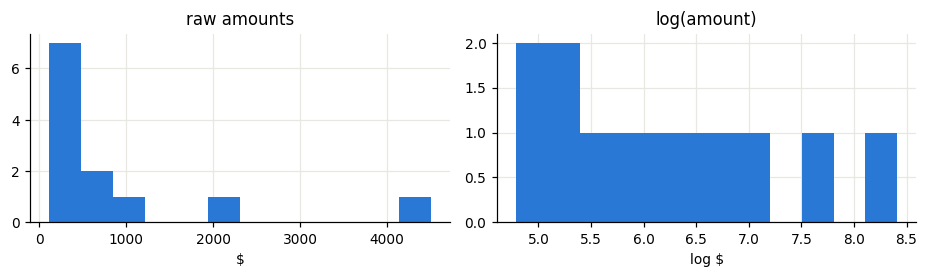

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 2.6))
ax[0].hist(amt, bins=12, color=BLUE); ax[0].set_title("raw amounts"); ax[0].set_xlabel("$")
ax[1].hist(np.log(amt), bins=12, color=BLUE); ax[1].set_title("log(amount)"); ax[1].set_xlabel("log $")
plt.tight_layout(); plt.show()

**What happened.** On the raw scale the rule accuses 17% of the data — far past the 5%
guideline. After the log it accuses nothing, because on that scale the data is symmetric.
Nothing about the data changed; we stopped using a symmetric ruler on a skewed quantity.

## 2.6 Multivariate outliers

> **Definition.** A **multivariate outlier** is a row that is ordinary in every column on its
> own, but impossible as a *combination*. Checking one column at a time cannot find it, by
> construction.
>
> The simplest way to see one is to build the column that expresses the relationship — a
> ratio, a rate, a difference — and look at that.

In [9]:
# EXAMPLE. Trade size and commission charged. Commission should be ~5 bps of size.
size = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 90], float)  # $000
comm = np.array([ 5, 10, 15, 20, 25, 30, 35, 40, 45,  50,  55,  60,  8], float)  # $

print(f"any SIZE unusual on its own?       flags {size[iqr_flags(size)]}")
print(f"any COMMISSION unusual on its own? flags {comm[iqr_flags(comm)]}")

rate = comm / size * 10          # commission in basis points of notional
print(f"\ncommission rate (bps): {np.round(rate, 2)}")

any SIZE unusual on its own?       flags []
any COMMISSION unusual on its own? flags []

commission rate (bps): [5.   5.   5.   5.   5.   5.   5.   5.   5.   5.   5.   5.   0.89]


**What happened.** Neither column flags anything: a size of 90 is ordinary, and a commission
of \$8 is ordinary. But *together* they are not — the last trade paid **0.89 bps** where
every other trade paid **5 bps**.

The tell is in the table: **size 90 appears twice**, once charged \$45 and once charged \$8.

For more than two columns the standard tools are the **Mahalanobis distance**, the
**Isolation Forest** and the **Local Outlier Factor** — but the idea is always this one.

# 3. Handling outliers

> **Definition.** A flag is a **question**, not a verdict. There are five possible answers,
> and the right one depends on the *cause*, not on the size of the number.

| Action | When to use it | What it costs |
|---|---|---|
| **Keep** | It is a genuine extreme | Later methods must tolerate it |
| **Fix** | A recoverable error: units, a typo, a sign | You need a source of truth |
| **Cap** | Heavy tail, you want to limit its influence | Deliberately biases the tail |
| **Transform** | The quantity is multiplicative | Changes how results are read |
| **Remove** | A confirmed error or contamination | Must be logged, never silent |

In [10]:
# EXAMPLE. Flag first, act second -- and never modify the original column in place.
df = pd.DataFrame({"broker": list("ABCDEFGHIJ"), "trades": x})

lo_f, hi_f = np.percentile(df.trades, [25, 75])
w = hi_f - lo_f
df["flagged"]       = (df.trades < lo_f - 1.5*w) | (df.trades > hi_f + 1.5*w)
df["trades_capped"] = df.trades.clip(lo_f - 1.5*w, hi_f + 1.5*w)   # capping keeps every row

print(df.to_string(index=False))
print(f"\nflagged {df.flagged.sum()} of {len(df)} rows ({df.flagged.mean():.0%})")

broker  trades  flagged  trades_capped
     A    22.0    False         22.000
     B    24.0    False         24.000
     C    25.0    False         25.000
     D    25.0    False         25.000
     E    26.0    False         26.000
     F    27.0    False         27.000
     G    28.0    False         28.000
     H    29.0    False         29.000
     I    31.0    False         31.000
     J   120.0     True         34.375

flagged 1 of 10 rows (10%)


**What happened.** The original `trades` column is untouched. We added a `flagged` column
saying *why*, and a separate capped column. Nothing was deleted, so the decision can still
be reviewed or reversed.

**The sentence to write down:** *"We removed 3 rows (0.8%) failing the rule `quantity > 0`."*
A silently smaller dataset is a bug; a logged removal is a result.

# 4. Inconsistencies

Fix these **before** looking for outliers. A column that mixes two currencies is measuring
the mixing, not the data.

## 4.1 The four kinds

The definition and the four kinds are in §1.2. Here is a table with all four in it at once.

In [11]:
# EXAMPLE. A seven-row blotter with something wrong in almost every column.
t = pd.DataFrame({
    "trade_id": ["T1", "T2", "T3", "T4", "T5", "T6", "T2"],
    "date":     ["2026-03-02", "03/03/2026", "2026-03-04", "2026-02-30",
                 "2026-03-05", "2026-03-06", "03/03/2026"],
    "venue":    ["NYSE", "nyse", " NYSE", "NASDAQ", "nasdaq", "NYSE", "nyse"],
    "qty":      [100, 250, -50, 400, 300, 150, 250],
    "price":    [52.10, 48.75, 51.00, -999.0, 49.80, 50.25, 48.75],
    "ccy":      ["USD", "USD", "USD", "USD", "EUR", "USD", "USD"],
    "status":   ["Filled", "FILLED", "filled", "Filled", "Filled", None, "FILLED"],
})
print(t.to_string(index=False))

trade_id       date  venue  qty   price ccy status
      T1 2026-03-02   NYSE  100   52.10 USD Filled
      T2 03/03/2026   nyse  250   48.75 USD FILLED
      T3 2026-03-04   NYSE  -50   51.00 USD filled
      T4 2026-02-30 NASDAQ  400 -999.00 USD Filled
      T5 2026-03-05 nasdaq  300   49.80 EUR Filled
      T6 2026-03-06   NYSE  150   50.25 USD    NaN
      T2 03/03/2026   nyse  250   48.75 USD FILLED


In [12]:
# Representation: normalise, then check how many distinct values survive.
print(f"venue spellings : {t.venue.nunique()}", end="")
t["venue"] = t.venue.str.strip().str.upper()            # trim spaces, then upper-case
print(f"  ->  {t.venue.nunique()}   {sorted(t.venue.unique())}")

print(f"status spellings: 3", end="")
t["status"] = t.status.str.upper()
print(f"  ->  {t.status.nunique()}")

# Format: parse explicitly. errors='coerce' turns failures into NaT -- countable, not silent.
t["date"] = pd.to_datetime(t.date, format="mixed", errors="coerce")
print(f"\ndates that could not be parsed: {t.date.isna().sum()}   (2026-02-30 does not exist)")

# Contradictions and sentinels.
print(f"impossible quantities (qty <= 0): {(t.qty <= 0).sum()}")
print(f"sentinel prices (-999)          : {(t.price == -999).sum()}")

venue spellings : 5  ->  2   ['NASDAQ', 'NYSE']
status spellings: 3  ->  1

dates that could not be parsed: 1   (2026-02-30 does not exist)
impossible quantities (qty <= 0): 1
sentinel prices (-999)          : 1


**What happened.** `errors="coerce"` is the important piece. Without it the parser either
crashes or silently leaves the column as text. With it, the bad date becomes `NaT` — a
failure you can **count**.

`-999` is a **sentinel**: a real number used to mean "missing". It must become `NaN`,
because otherwise it gets averaged.

## 4.2 Duplicates

> **Definition.** Three kinds, in increasing difficulty:
>
> | Kind | What it means | How to find it |
> |---|---|---|
> | **Exact** | Every field identical | `df.drop_duplicates()` |
> | **Key** | Same ID, different values | `df.duplicated(subset="id")` |
> | **Fuzzy** | Same entity, spelled differently | text similarity |
>
> Key duplicates need a **survivor rule** — which copy wins — and that rule is a decision
> someone must sign off, not a technicality.

In [13]:
# EXAMPLE. The same seven-row table.
print(f"rows                  : {len(t)}")
print(f"exact duplicate rows  : {t.duplicated().sum()}")
print(f"repeated trade_ids    : {t.trade_id.duplicated().sum()}")

t2 = t.drop_duplicates()
print(f"\nafter drop_duplicates : {len(t2)} rows")
print(f"trade_id unique now   : {t2.trade_id.is_unique}")

rows                  : 7
exact duplicate rows  : 1
repeated trade_ids    : 1

after drop_duplicates : 6 rows
trade_id unique now   : True


**What happened.** Here the duplicate was exact, so one call solved it. That is the easy case.

Had the two `T2` rows disagreed — say one priced at 48.75 and the other at 48.85 — no code
could choose between them. You would need a written rule ("keep the most recent", "keep the
settled one") because picking a price *is* an accounting decision.

# 5. Assessing data quality

> **Definition.** Report quality as six numbers, each in $[0,1]$:

| Dimension | Question | How to measure |
|---|---|---|
| **Completeness** | Are values present? | non-missing ÷ total |
| **Validity** | Do values obey the rules? | passing ÷ total |
| **Accuracy** | Do values match reality? | compare to a trusted source |
| **Consistency** | Do related values agree? | violations ÷ total |
| **Uniqueness** | One row per real thing? | distinct keys ÷ rows |
| **Timeliness** | Is it fresh enough? | age vs. the deadline |

Five of these can be computed inside the file. **Accuracy cannot** — it needs an outside
source. Say so, rather than reporting five and implying six.

In [14]:
# EXAMPLE. A quality report on the same small blotter.
report = {
    "rows":                len(t),
    "completeness":        t.notna().to_numpy().mean(),
    "validity: date":      t.date.notna().mean(),
    "validity: qty > 0":   (t.qty > 0).mean(),
    "validity: price > 0": (t.price > 0).mean(),
    "uniqueness":          t.trade_id.nunique() / len(t),
    "accuracy":            np.nan,           # cannot be measured from inside the file
}
for k, v in report.items():
    print(f"  {k:<22} {v:.3f}" if isinstance(v, float) else f"  {k:<22} {v}")

  rows                   7
  completeness           0.959
  validity: date         0.857
  validity: qty > 0      0.857
  validity: price > 0    0.857
  uniqueness             0.857
  accuracy               nan


**What happened.** Completeness is **0.96** — the table looks almost perfect. But validity on
price is **0.857** and uniqueness is **0.857**, because one price is a sentinel and one ID
repeats.

This is the whole reason to report six numbers and not one. A single "quality score" would
have hidden both problems behind a high completeness figure.

# 6. Practice problems

Eleven problems, grouped by the section they come from. Solutions are in §7.

***
### On §1 — Definitions

**Problem 1.** For each of these, name the kind (error / contamination / genuine extreme)
and say what you would do:

1. A recorded body temperature of `-1`.
2. One purchase of \$48,000 in a table of supermarket receipts.
3. A daily stock return of `-22%` on a day the market crashed.
4. A customer with 4,812 orders in a single day, in a table of consumer purchases.

***
### On §2 — Detecting outliers

Problems 2 to 5 all use the same list:

$$[\,12,\;14,\;14,\;15,\;16,\;16,\;17,\;18,\;19,\;21,\;22,\;95\,]$$

**Problem 2 (z-score).**
1. Compute the mean, the standard deviation, and the largest $|z|$.
2. Does the $|z| > 3$ rule flag 95?
3. Compute the ceiling $(n-1)/\sqrt{n}$. How close is your answer in (1) to it?

**Problem 3 (IQR rule).**
1. Compute $Q_1$, $Q_3$ and the IQR.
2. Compute the two fences.
3. Which values are flagged?

**Problem 4 (modified z-score).**
1. Find the median and the MAD.
2. Compute the modified z-score of 95.
3. Which of the three rules would you report, and why?

**Problem 5 (masking).** Now add a second outlier, `90`, to the same list.
1. What is the largest $|z|$ now? Does $|z| > 3$ flag anything?
2. Do the IQR rule and the modified z-score still flag both?
3. What is this phenomenon called?

**Problem 6 (skew).** For the amounts `[45, 60, 75, 90, 130, 190, 280, 430, 700, 1500]`:
1. Apply the IQR rule to the raw values. What is flagged?
2. Apply it to `np.log` of the values. What is flagged now?
3. Which answer would you report to a manager, and what would you say?

**Problem 7 (multivariate).** Trades and commissions:

```
size ($000): 20  40  60  80  100  30  50  70  90  110  55
commission : 10  20  30  40   50  15  25  35  45   55  55
```

1. Does the IQR rule flag anything in `size` alone? In `commission` alone?
2. Compute the commission rate `commission / size * 10` for each trade.
3. Which trade is wrong, and how do you know?

***
### On §3 — Handling outliers

**Problem 8.** For each flagged value, say **keep / fix / cap / remove**, and state what
evidence you would need first:

1. A temperature of `-999` in a patient record.
2. A house price of \$12,000,000 in a table of national house sales.
3. A person's height recorded as `1.80` where every other value is near `180`.
4. A single trade 500 times larger than any other, from the desk that does block trades.

***
### On §4 — Inconsistencies

**Problem 9.** Using the seven-row blotter from §4.1:
1. List every distinct problem you can see (there are at least seven).
2. Which single column would you fix *first*, and why?
3. Row T5 is in EUR while the rest are in USD. Why is this dangerous even though nothing
   about the row looks wrong?

**Problem 10 (duplicates).** A customer table contains these four rows:

```
1  Jon Smith,   12 Oak St,     jsmith@mail.com
2  John Smith,  12 Oak Street, jsmith@mail.com
3  John Smith,  12 Oak Street, jsmith@mail.com
4  J. Smith,    14 Oak Street, jbsmith@mail.com
```

1. Which pair is an **exact** duplicate?
2. Which rows are probably the same person, and what evidence says so?
3. Which row would you refuse to merge automatically, and why?

***
### On §5 — Assessing data quality

**Problem 11.** Using the seven-row blotter:
1. Compute completeness, validity on `qty`, and uniqueness.
2. Which dimension looks *best* and which looks *worst*?
3. The table is used to calculate today's total traded value. Which single defect matters
   most for that purpose, and why?

# 7. Solutions

### Solution 1 — kinds of outlier

| | Kind | Action | Why |
|---|---|---|---|
| 1 | **Error** | Convert to missing | `-1` is a sentinel; no body is at −1 degrees |
| 2 | **Contamination** | Remove, or model separately | A \$48,000 supermarket receipt is a business, not a shopper |
| 3 | **Genuine extreme** | **Keep** | Crash days are real and are exactly what risk work studies |
| 4 | **Contamination** | Remove from the consumer analysis | A bot or a business account, not a consumer |

Three of the four are *not* deleted outright. Only one is a plain mistake.

In [15]:
# --- Solution 2: the z-score ------------------------------------------------
p = np.array([12, 14, 14, 15, 16, 16, 17, 18, 19, 21, 22, 95], float)
n = len(p)

print(f"1)  mean = {p.mean():.4f}   sd = {p.std(ddof=1):.4f}")
print(f"    largest |z| = {np.abs((p - p.mean()) / p.std(ddof=1)).max():.4f}")
print(f"2)  flagged at |z| > 3: {p[np.abs((p - p.mean())/p.std(ddof=1)) > 3]}  -> yes, but only just")
print(f"3)  ceiling = (n-1)/sqrt(n) = {(n-1)/np.sqrt(n):.4f}")
print(f"    the observed 3.1491 is {3.1491/((n-1)/np.sqrt(n)):.1%} of the maximum possible")

1)  mean = 23.2500   sd = 22.7841
    largest |z| = 3.1491
2)  flagged at |z| > 3: [95.]  -> yes, but only just
3)  ceiling = (n-1)/sqrt(n) = 3.1754
    the observed 3.1491 is 99.2% of the maximum possible


**Solution 2, in words.** The rule fires, but barely: 3.149 against a threshold of 3. The
ceiling at $n = 12$ is **3.175**, so the observed value is **99.2%** of the largest z-score
this sample size can *ever* produce. The rule did not detect an outlier so much as run out of
room. Below about $n = 15$, do not use the z-score for outlier detection.

In [16]:
# --- Solution 3: the IQR rule -----------------------------------------------
q1, q3 = np.percentile(p, [25, 75])
iqr = q3 - q1
print(f"1)  Q1 = {q1:.2f}   Q3 = {q3:.2f}   IQR = {iqr:.2f}")
print(f"2)  fences = [{q1 - 1.5*iqr:.3f}, {q3 + 1.5*iqr:.3f}]")
print(f"3)  flagged: {p[(p < q1 - 1.5*iqr) | (p > q3 + 1.5*iqr)]}")

1)  Q1 = 14.75   Q3 = 19.50   IQR = 4.75
2)  fences = [7.625, 26.625]
3)  flagged: [95.]


In [17]:
# --- Solution 4: the modified z-score ---------------------------------------
med_p = np.median(p)
mad_p = np.median(np.abs(p - med_p))
print(f"1)  median = {med_p:.2f}   MAD = {mad_p:.2f}")
print(f"2)  modified z of 95 = 0.6745 * (95 - {med_p:.1f}) / {mad_p:.1f} = {0.6745*(95-med_p)/mad_p:.4f}")
print(f"\n    sd with 95    = {p.std(ddof=1):.4f}")
print(f"    sd without 95 = {p[p < 90].std(ddof=1):.4f}   -> the outlier inflated it {p.std(ddof=1)/p[p<90].std(ddof=1):.1f}x")

1)  median = 16.50   MAD = 2.50
2)  modified z of 95 = 0.6745 * (95 - 16.5) / 2.5 = 21.1793

    sd with 95    = 22.7841
    sd without 95 = 3.0689   -> the outlier inflated it 7.4x


**Solution 4, part 3.** Report the **IQR rule or the modified z-score**. Both give an
unambiguous answer (the modified z is 21.2, nowhere near the 3.5 threshold). The z-score is
borderline *only because* 95 inflated the standard deviation from 3.07 to 22.78 — it is being
judged by a ruler it bent itself.

In [18]:
# --- Solution 5: masking ----------------------------------------------------
p2 = np.append(p, 90.0)
z2p = (p2 - p2.mean()) / p2.std(ddof=1)
q1c, q3c = np.percentile(p2, [25, 75]); wc = q3c - q1c
med_c = np.median(p2); mad_c = np.median(np.abs(p2 - med_c))
M_c = 0.6745 * (p2 - med_c) / mad_c

print(f"1)  largest |z| = {np.abs(z2p).max():.4f}   flagged at |z|>3: {p2[np.abs(z2p) > 3]}  -> NOTHING")
print(f"2)  IQR        flags: {p2[(p2 < q1c-1.5*wc) | (p2 > q3c+1.5*wc)]}")
print(f"    modified z flags: {p2[np.abs(M_c) > 3.5]}")
print(f"3)  masking")
print(f"\n    for comparison, with only ONE outlier the largest |z| was 3.1491")

1)  largest |z| = 2.3283   flagged at |z|>3: []  -> NOTHING
2)  IQR        flags: [95. 90.]
    modified z flags: [95. 90.]
3)  masking

    for comparison, with only ONE outlier the largest |z| was 3.1491


**Solution 5, in words.** With one outlier the z-score just barely fired. With **two**, it
fires **not at all** — the largest $|z|$ fell to 2.33. The data got worse and the rule went
quiet. Both robust rules still flag both values.

That is masking, and it is the single best argument for using the median and the MAD when
your purpose is *detection*.

In [19]:
# --- Solution 6: skew -------------------------------------------------------
q = np.array([45, 60, 75, 90, 130, 190, 280, 430, 700, 1500], float)
fr, fl = iqr_flags(q), iqr_flags(np.log(q))
print(f"1)  raw      : flags {q[fr]}   ({fr.mean():.0%} of rows)")
print(f"2)  log scale: flags {q[fl]}   ({fl.mean():.0%} of rows)")

1)  raw      : flags [1500.]   (10% of rows)
2)  log scale: flags []   (0% of rows)


**Solution 6, part 3.** Report that **nothing is wrong with the data**. The raw rule accuses
1,500 only because the amounts are right-skewed, and after a log transform no value is unusual
at all. What you would tell a manager: *"The largest transaction is not an error — transaction
sizes are naturally skewed, and on a log scale this one is unremarkable."*

In [20]:
# --- Solution 7: multivariate ----------------------------------------------
s2 = np.array([20, 40, 60, 80, 100, 30, 50, 70, 90, 110, 55], float)
c2 = np.array([10, 20, 30, 40,  50, 15, 25, 35, 45,  55, 55], float)

print(f"1)  size flags      : {s2[iqr_flags(s2)]}   (none)")
print(f"    commission flags: {c2[iqr_flags(c2)]}   (none)")
r2 = c2 / s2 * 10
print(f"2)  rate (bps): {np.round(r2, 2)}")
print(f"3)  the last trade: size {s2[-1]:.0f}k charged {c2[-1]:.0f} = {r2[-1]:.1f} bps, "
      f"against {r2[0]:.1f} bps for every other trade")

1)  size flags      : []   (none)
    commission flags: []   (none)
2)  rate (bps): [ 5.  5.  5.  5.  5.  5.  5.  5.  5.  5. 10.]
3)  the last trade: size 55k charged 55 = 10.0 bps, against 5.0 bps for every other trade


**Solution 7, in words.** A size of 55 is ordinary; a commission of 55 is ordinary (trade 10
pays exactly that). Only the **pair** is wrong: this client was charged the commission of a
110k trade on a 55k trade — **double the going rate**. No single-column rule can see it,
because neither number is unusual on its own.

### Solution 8 — what to do

| | Action | Evidence needed first |
|---|---|---|
| 1 | **Fix** — convert `-999` to missing | The system's documented missing-value code, and whether it uses others (`-1`, `9999`) |
| 2 | **Keep** | Check it against the address; \$12M houses exist. If real, keep it and report the median price, not the mean |
| 3 | **Fix** — multiply by 100 | Confirm the pattern holds for *every* such row before applying it |
| 4 | **Keep** | The desk's mandate. A block desk trading a block is the business, not an error |

Only case 1 is a clear error. Notice that **none** of the four is simply deleted — and that
the largest number in the list (case 4) is the one you most want to keep.

### Solution 9 — inconsistencies

**Part 1 — the problems.**

1. `venue` in five spellings for two venues (`NYSE`, `nyse`, `" NYSE"`, `NASDAQ`, `nasdaq`)
2. `date` in two formats (`2026-03-02` and `03/03/2026`)
3. `2026-02-30` is not a real date — February has no 30th
4. `qty = -50` on row T3 — impossible for an executed trade
5. `price = -999` on row T4 — a sentinel, not a price
6. `status` in three cases (`Filled`, `FILLED`, `filled`)
7. `status` missing on row T6
8. Row T2 appears **twice**, identically
9. Row T5 is in EUR while every other row is USD

**Part 2 — fix first?** The **date** column. Until it parses, no ordering, no filtering by
period, and no settle-versus-trade check is possible. Nothing downstream works without it.

**Part 3 — why EUR is dangerous.** Because the row looks *perfectly clean*. Nothing about
`300 × 49.80` signals a problem. If you total the column you silently add euros to dollars and
get a number that is wrong by roughly 8% with no error message anywhere. **The defects that
survive inspection are the ones that do the damage.**

### Solution 10 — duplicates

1. **Rows 2 and 3** are the exact duplicate — every field identical.
2. **Rows 1, 2 and 3** are almost certainly the same person: the same email address, the same
   street once `St` and `Street` are normalised, and `Jon`/`John` is a common variant. The
   email is the strongest evidence, because it is a near-unique identifier.
3. **Row 4.** The name is compatible (`J. Smith`), but the house number is **14**, not 12, and
   the email is *different* (`jbsmith@`). That could be a different family member at a
   neighbouring address. Merging would combine two real people into one; send it to a human.

In [21]:
# --- Solution 11: quality ---------------------------------------------------
print(f"1)  completeness   = {t.notna().to_numpy().mean():.4f}")
print(f"    validity (qty) = {(t.qty > 0).mean():.4f}   ({(t.qty <= 0).sum()} row fails)")
print(f"    uniqueness     = {t.trade_id.nunique()/len(t):.4f}   ({t.trade_id.duplicated().sum()} repeated id)")
print(f"\n2)  best  : completeness ({t.notna().to_numpy().mean():.3f})")
print(f"    worst : validity on price and uniqueness (both {t.trade_id.nunique()/len(t):.3f})")

1)  completeness   = 0.9592
    validity (qty) = 0.8571   (1 row fails)
    uniqueness     = 0.8571   (1 repeated id)

2)  best  : completeness (0.959)
    worst : validity on price and uniqueness (both 0.857)


**Solution 11, part 3.** For a **total traded value**, the worst defect is the **EUR row**.

The duplicate `T2` would inflate the total by one trade, and the `-999` price would make it
wildly negative — but both are *visible*: one is a repeated ID, the other an absurd number,
and either would be caught by a glance at the result.

The currency mix produces a total that is plausible, undetectable, and **wrong**. The quantity
of `-50` is second worst for the same reason — it silently subtracts instead of adding.

**The lesson:** rank defects by their effect on *your* purpose, not by how ugly they look.

# 8. Glossary

| Term | Meaning |
|---|---|
| **Breakdown point** | The fraction of data that can be made arbitrarily bad before a statistic becomes meaningless. Mean and standard deviation: 0%. Median and MAD: 50%. |
| **Completeness** | Non-missing cells ÷ total cells. |
| **Consistency** | Whether related values agree with each other; 1 − (violations ÷ total). |
| **Contamination** | A real value that came from a different population than the one you meant to study. |
| **Coercion** | Forcing a value into a type. `errors="coerce"` turns failures into `NaN`/`NaT` so they can be counted. |
| **Fences** | The IQR rule's two bounds, $Q_1 - 1.5\,\mathrm{IQR}$ and $Q_3 + 1.5\,\mathrm{IQR}$. |
| **IQR** | Interquartile range, $Q_3 - Q_1$: the width of the middle half of the data. |
| **Key duplicate** | Two rows with the same identifier but different values; needs a survivor rule. |
| **MAD** | Median absolute deviation, $\operatorname{median}(|x_i - \tilde{x}|)$. A robust measure of spread. |
| **Masking** | Outliers inflating the spread estimate so much that they hide one another. |
| **Mean** ($\bar{x}$) | The arithmetic average. Breakdown point 0% — one bad value moves it anywhere. |
| **Median** ($\tilde{x}$) | The middle value once sorted. Breakdown point 50%. |
| **Modified z-score** | $M_i = 0.6745(x_i - \tilde{x})/\mathrm{MAD}$; flag at 3.5. The robust counterpart of the z-score. |
| **Multivariate outlier** | A row that is ordinary in every column alone but impossible as a combination. |
| **NaN / NaT** | The missing-value markers for numbers and for timestamps. `NaN != NaN`, so test with `.isna()`. |
| **Outlier** | A value far from the bulk of the data, given an assumed distribution. |
| **Quartiles** ($Q_1$, $Q_3$) | The values one quarter and three quarters of the way up the sorted data. |
| **Robust** | Little affected when a small part of the data is replaced by arbitrary values. |
| **Sentinel value** | A real number used to mean "missing" — `-999`, `9999`, `0`. Never average one. |
| **Skew** | A distribution with one long tail. Right-skewed data has large values *by nature*, not by error. |
| **Standard deviation** ($s$) | The usual measure of spread, $\sqrt{\frac{1}{n-1}\sum(x_i-\bar{x})^2}$. Use `ddof=1`. |
| **Timeliness** | Whether the data is fresh enough for the decision, measured against a deadline. |
| **Uniqueness** | Distinct keys ÷ rows. Below 1 means the key repeats. |
| **Validity** | Whether values obey the rules — type, range, pattern, permitted list. |
| **Winsorise (cap)** | Replace values beyond a threshold *with* that threshold. Keeps the row count unchanged. |
| **z-score** | $z_i = (x_i - \bar{x})/s$; flag at 3. Cannot exceed $(n-1)/\sqrt{n}$. |

***

### The one sentence

> An outlier is a question, not a verdict — and deleting it before you answer the question is
> how analyses go quietly wrong.